# Text Cleaning & Exploratory Data Analysis (IMDb)

**Objective.**

Apply a deterministic, POS-aware cleaning pipeline and produce EDA visuals to guide feature choices and model design.

**Outputs**
- `data/processed/cleaned_train.csv`, `cleaned_val.csv`, `cleaned_test.csv`
- Figures saved to `reports/figures/` (also displayed inline)
- `reports/tables/eda_stats.json` (length stats, vocab size, etc.)


## 1) Imports & Project Bootstrap

We ensure `src/` is importable whether the notebook runs from `notebooks/` or repo root.


In [10]:
from pathlib import Path
import sys

import json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import SEED, DATA_PROCESSED, REPORTS_TAB
from src.preprocess import clean_series, preview_cleaning
from src.plots import save_fig

sns.set(context="notebook")


## 2) Parameters

- **Cleaning pipeline:** lowercase → strip HTML/URLs → keep only `!?` from punctuation → tokenize → POS-aware lemmatize → remove stopwords → collapse spaces
- **Random seed:** 42 (used for sampling previews only)
- **Outputs:** cleaned CSVs and EDA tables/figures under `reports/`


In [11]:
PREVIEW_N = 5  # number of examples to show

## 3) Load original splits

We load the `train/val/test.csv` created by the ingest notebook to keep the exact stratified partitions.


In [12]:
train = pd.read_csv(DATA_PROCESSED / "train.csv")
val   = pd.read_csv(DATA_PROCESSED / "val.csv")
test  = pd.read_csv(DATA_PROCESSED / "test.csv")

print("Shapes:", {"train": train.shape, "val": val.shape, "test": test.shape})
train.head(3)

Shapes: {'train': (39665, 3), 'val': (4958, 3), 'test': (4959, 3)}


,doc_id,text,label
0,80445025942f4e2f829b6c107055c8b0,I am one of Jehovah's Witnesses and I also wor...,1
1,22eb48cc28a3a8f8fc05afb8412e6bc9,Amongst the standard one liner type action fil...,1
2,a240f061802950569f9b894dbf1b3a60,Realty television crew are assigned to cover a...,0


**Observations**
- The split sizes match the target 80/10/10 (train 39,665 • val 4,958 • test 4,959), consistent with the ingest notebook.
- All splits have exactly 3 columns (`doc_id,text,label`), confirming the schema contract.


## 4) Cleaning preview (before/after)

We preview a few samples to validate the transformation and capture report screenshots.
This is so that we can see exactly what “cleaning” does to raw text.


In [13]:
samples = train["text"].sample(PREVIEW_N, random_state=SEED).tolist()
for i, (orig, cleaned) in enumerate(preview_cleaning(samples, n=PREVIEW_N), 1):
    o = orig.replace("\n", " ")
    print(f"{i}. ORIG:  {o[:200]}{'...' if len(o) > 200 else ''}")
    print(f"   CLEAN: {cleaned[:200]}{'...' if len(cleaned) > 200 else ''}\n")

1. ORIG:  Two escaped convicts step out of the woods and shoot two campers in the head. That's the first scene, and it made me wince, fearing what was in store. But by the end of the first half hour I was all s...
   CLEAN: two escape convict step wood shoot two camper head first scene make wince fear store end first half hour sweep flood image care least character aghast execrable film curious see truly low could sink f...

2. ORIG:  As an avid Disney fan, I was not totally impressed by this movie, certainly not motivated enough to catch it in the theaters. I am, however, so glad that I caught it on DVD and watched the special fea...
   CLEAN: avid disney fan totally impressed movie certainly motivate enough catch theater however glad catch dvd watch special feature must check moose commentary entire movie view commentary rutt tuke comic re...

3. ORIG:  Like many others, I had been attracted to the combination of Pollack, Ford and Scott-Thomas. I had enjoyed the work of Pollack and F

**Observations**
- HTML tags/URLs are removed; only `!/?` punctuation is retained by design.
- POS-aware lemmatization reduces inflected forms (fore example “escaped/escaping” → **escape**).
- Stopword removal increases signal density without obviously deleting sentiment-bearing words.
- The semantic content is preserved, which is important for downstream models to learn sentiment cues rather than formatting noise.


## 5) Apply cleaning to train/val/test

Run the deterministic cleaning pipeline across all splits.  
**Why this matters:** ensures downstream features (TF-IDF, sequences) are derived from a **consistent** and **reproducible** text representation.


In [14]:
def apply_clean_and_drop_empty(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    out = df.copy()
    out["text"] = clean_series(out["text"])
    before = len(out)
    out = out[out["text"].str.strip().astype(bool)].reset_index(drop=True)
    dropped = before - len(out)
    return out, dropped

train_c, drop_tr = apply_clean_and_drop_empty(train)
val_c,   drop_va = apply_clean_and_drop_empty(val)
test_c,  drop_te = apply_clean_and_drop_empty(test)

print("Dropped emptied rows:", {"train": drop_tr, "val": drop_va, "test": drop_te})
train_c.head(3)


Dropped emptied rows: {'train': 0, 'val': 0, 'test': 0}


,doc_id,text,label
0,80445025942f4e2f829b6c107055c8b0,one jehovah witness also work acute care medic...,1
1,22eb48cc28a3a8f8fc05afb8412e6bc9,amongst standard one liner type action film ac...,1
2,a240f061802950569f9b894dbf1b3a60,realty television crew assign cover small town...,0


**Observations**
- No documents collapsed to empty text after cleaning (`dropped = 0` for all splits).  
  Hence,no need for imputation or special handling.


## 6) Persist cleaned datasets

Save cleaned `train/val/test` as CSVs for **reuse** by ML and DL notebooks.  
This avoids recomputing cleaning and guarantees the same text basis for all experiments.


In [15]:
train_c.to_csv(DATA_PROCESSED / "cleaned_train.csv", index=False)
val_c.to_csv(  DATA_PROCESSED / "cleaned_val.csv",   index=False)
test_c.to_csv( DATA_PROCESSED / "cleaned_test.csv",  index=False)

print("Saved:", [p.name for p in (DATA_PROCESSED / "cleaned_train.csv",
                                  DATA_PROCESSED / "cleaned_val.csv",
                                  DATA_PROCESSED / "cleaned_test.csv")])


Saved: ['cleaned_train.csv', 'cleaned_val.csv', 'cleaned_test.csv']


## 7) Token length statistics

Compute token length stats (mean, median, p95) for each split and save them to `reports/tables/eda_stats.json`.  
**Why this matters:** guides sequence length decisions for DL and informs TF-IDF `max_features` and `ngram` settings.


In [16]:
def token_lengths(series: pd.Series) -> np.ndarray:
    return series.astype(str).str.split().map(len).to_numpy()

train_len = token_lengths(train_c["text"])
val_len   = token_lengths(val_c["text"])
test_len  = token_lengths(test_c["text"])

eda_stats = {
    "train": {"mean_len": float(np.mean(train_len)), "median_len": float(np.median(train_len)), "p95_len": float(np.percentile(train_len,95))},
    "val":   {"mean_len": float(np.mean(val_len)),   "median_len": float(np.median(val_len)),   "p95_len": float(np.percentile(val_len,95))},
    "test":  {"mean_len": float(np.mean(test_len)),  "median_len": float(np.median(test_len)),  "p95_len": float(np.percentile(test_len,95))}
}

REPORTS_TAB.mkdir(parents=True, exist_ok=True)
with open(REPORTS_TAB / "eda_stats.json", "w") as f:
    json.dump(eda_stats, f, indent=2)

eda_stats


{'train': {'mean_len': 118.63224505231312,
  'median_len': 88.0,
  'p95_len': 306.0},
 'val': {'mean_len': 117.68031464300121, 'median_len': 87.0, 'p95_len': 309.0},
 'test': {'mean_len': 118.2087114337568, 'median_len': 88.0, 'p95_len': 309.0}}

## 8) EDA Plot — Class balance (train)

Confirm class stratification is preserved **after cleaning**.  
Saved via our helper to ensure figures are available both inline and as files.


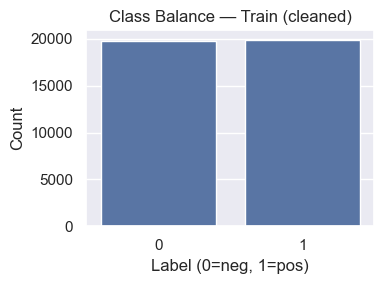

In [17]:
plt.figure(figsize=(4,3))
sns.countplot(x="label", data=train_c)
plt.title("Class Balance — Train (cleaned)")
plt.xlabel("Label (0=neg, 1=pos)"); plt.ylabel("Count")
save_fig("eda_class_balance_train")
plt.show()


**Observations**
- The class distribution is essentially **50/50** after cleaning.
  - Accuracy is a reliable summary, we will still report **Macro-F1** as the primary metric to guard against any subtle imbalance.


## 9) EDA Plot — Token length distribution (cleaned train)

Examine the distribution of document lengths to select appropriate padding/truncation for DL and to anticipate sparsity for ML vectorizers.


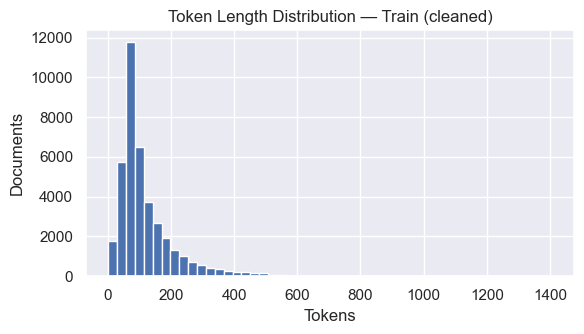

In [18]:
plt.figure(figsize=(6,3.5))
plt.hist(train_len, bins=50)
plt.title("Token Length Distribution — Train (cleaned)")
plt.xlabel("Tokens"); plt.ylabel("Documents")
save_fig("eda_token_length_hist_train")
plt.show()


**Observations**
- Strong right-skew: most reviews are ≤ 150 tokens and a long tail extends beyond 500 tokens.
- **Conclusion:** Padding to 300 tokens keeps waste manageable.


## 10) EDA Plot — Length by class (boxplot)

Check whether one class is systematically longer/shorter; significant differences can bias certain models or metrics.


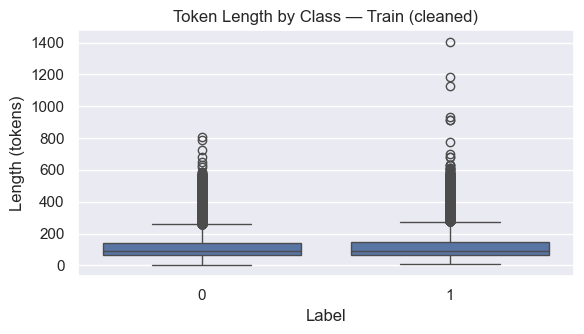

In [19]:
tmp = train_c.copy()
tmp["len"] = token_lengths(tmp["text"])
plt.figure(figsize=(6,3.5))
sns.boxplot(x="label", y="len", data=tmp)
plt.title("Token Length by Class — Train (cleaned)")
plt.xlabel("Label"); plt.ylabel("Length (tokens)")
save_fig("eda_len_box_by_class")
plt.show()


**Observations**
- Length distributions are **very similar across classes** (medians and IQRs overlap).  


## 11) EDA Plot — Top unigrams (per class)

Reveal discriminative words and potential leakage (e.g., named entities) to watch for.  
We exclude standalone `!/?` from top token lists to focus on lexical items.


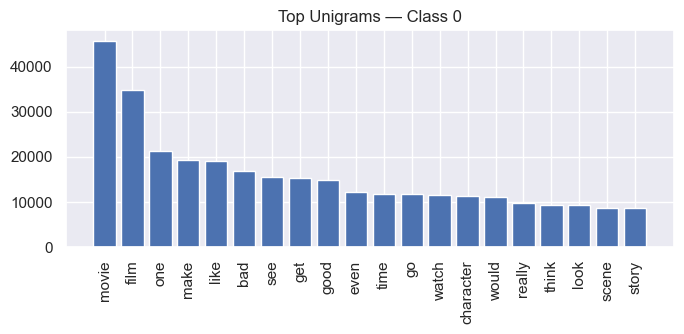

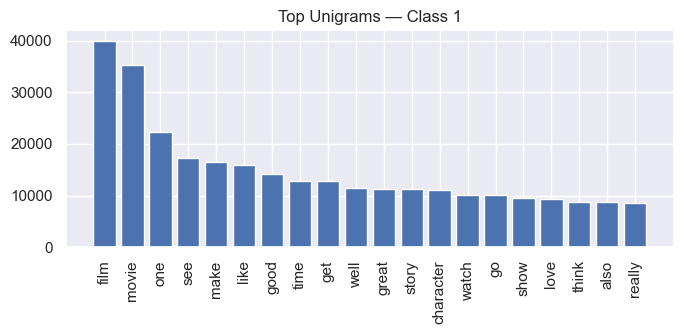

In [20]:
def top_unigrams_by_class(df: pd.DataFrame, n=20):
    rows = []
    for lab in (0,1):
        tokens = " ".join(df.loc[df.label==lab, "text"]).split()
        cnt = Counter(tokens)
        for p in ["!", "?"]:
            cnt.pop(p, None)
        rows.append((lab, cnt.most_common(n)))
    return rows

tops = top_unigrams_by_class(train_c, n=20)
for lab, pairs in tops:
    xs, ys = zip(*pairs) if pairs else ([], [])
    plt.figure(figsize=(7,3.5))
    plt.bar(xs, ys)
    plt.title(f"Top Unigrams — Class {lab}")
    plt.xticks(rotation=90)
    save_fig(f"eda_top_unigrams_class{lab}")
    plt.show()


**Observations**
- Domain tokens (**movie**, **film**, **character**) dominate both classes — neutral but frequent.  
- Clear sentiment carriers appear (neg: **bad**, **waste**, **worst**; pos: **great**, **love**, **best**, **well**).
- **Implication:** Word-level TF-IDF with n-grams should perform well; consider **vocabulary pruning** (min_df ≥ 2/5) to reduce noise from rare tokens.


## 12) EDA Plot — Top bigrams (per class)

Surface short sentiment-bearing phrases (e.g., “not good”, “highly recommend”) that n-gram features and Transformers can exploit.


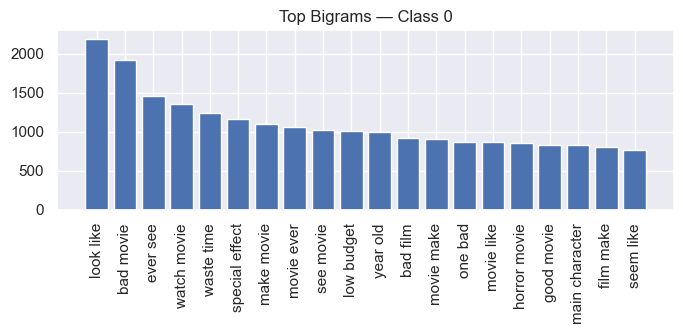

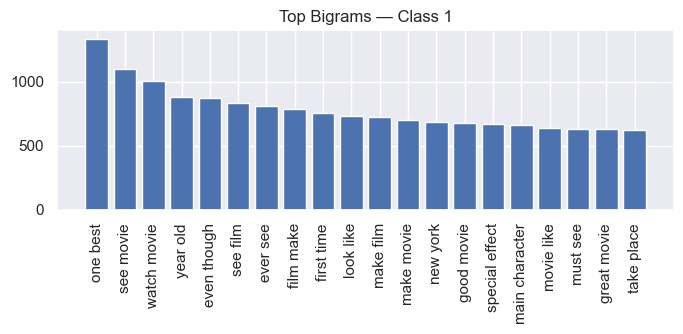

In [ ]:
def count_ngrams(df: pd.DataFrame, n=2, lab=None, top=20):
    cnt = Counter()
    texts = df.loc[df.label==lab, "text"].tolist() if lab in (0,1) else df["text"].tolist()
    for t in texts:
        toks = t.split()
        if n == 2:
            grams = zip(toks, toks[1:])
        elif n == 3:
            grams = zip(toks, toks[1:], toks[2:])
        else:
            continue
        cnt.update([" ".join(g) for g in grams])
    for p in ["!", "?"]:
        cnt.pop(p, None)
    return cnt.most_common(top)

for lab in (0,1):
    pairs = count_ngrams(train_c, n=2, lab=lab, top=20)
    xs, ys = zip(*pairs) if pairs else ([], [])
    plt.figure(figsize=(7,3.5))
    plt.bar(xs, ys)
    plt.title(f"Top Bigrams — Class {lab}")
    plt.xticks(rotation=90)
    save_fig(f"eda_top_bigrams_class{lab}")
    plt.show()


**Observations**
- Negative bigrams: **bad movie**, **waste time**, **low budget**, **one bad**.  
- Positive bigrams: **one best**, **must see**, **good movie**, **great movie**.
- **Implication:** **n-grams=(1,2)** will capture much of the sentiment signal for LR/SVM. Char n-grams can further help with spelling/emphasis variants.


## 13) EDA Plot — Top trigrams (overall)

Look for multiword expressions and common rhetorical patterns that may inform n-gram ranges or phrase handling.


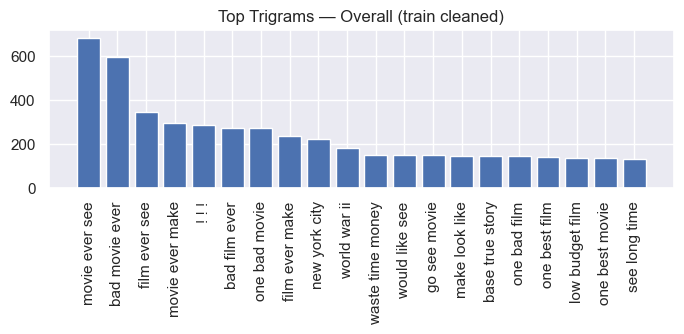

In [22]:
pairs = count_ngrams(train_c, n=3, lab=None, top=20)
xs, ys = zip(*pairs) if pairs else ([], [])
plt.figure(figsize=(7,3.5))
plt.bar(xs, ys)
plt.title("Top Trigrams — Overall (train cleaned)")
plt.xticks(rotation=90)
save_fig("eda_top_trigrams_overall")
plt.show()


**Observations**
- Frequent trigrams include emphatic patterns (**movie ever see**, **bad movie ever**) and location/time phrases (**new york city**, **world war ii**).
- `!!!` appears among common trigrams due to retained punctuation. This is a deliberately sparse but informative cue.
- **Implication:** Trigrams add incremental signal; for classic ML we’ll keep them out initially to control dimensionality, but DL will model longer context.


## 14) EDA Plot — Zipf curve (rank vs frequency, log–log)

Validate the typical long-tail vocabulary distribution in natural language; supports decisions about regularization and vocabulary size.


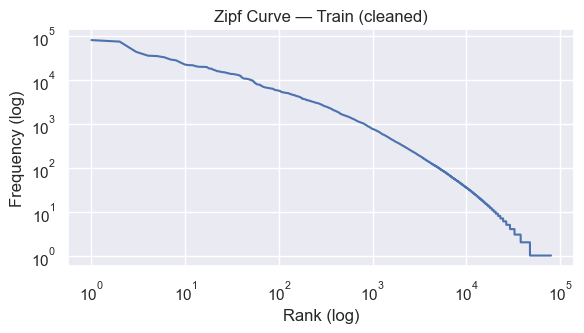

In [23]:
cnt = Counter(" ".join(train_c["text"]).split())
freqs = np.array(sorted(cnt.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(6,3.5))
plt.loglog(ranks, freqs)
plt.title("Zipf Curve — Train (cleaned)")
plt.xlabel("Rank (log)"); plt.ylabel("Frequency (log)")
save_fig("eda_zipf_curve")
plt.show()


**Observations**
- The curve shows a typical **Zipfian** distribution (long tail).  
- **Implication:** Strong regularization is important; for TF-IDF, use we will use `sublinear_tf=True`, prune rare tokens (`min_df ≥ 2/5`), and cap `max_features` (100k–200k).


## 15) EDA Plot — Punctuation density by class

Quantify `!/?` intensity per document as a crude sentiment signal.  
Useful as a feature for ML baselines and as a robustness diagnostic later.


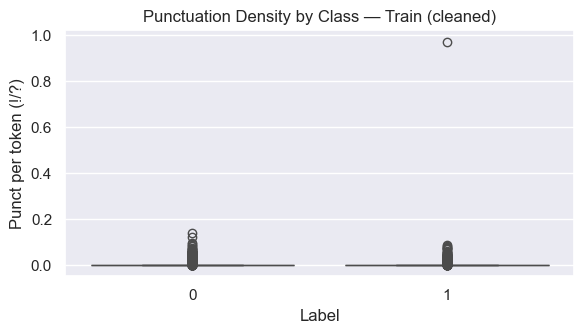

In [24]:
def punct_density(s: str) -> float:
    if not s:
        return 0.0
    exq = s.count("!") + s.count("?")
    return exq / max(1, len(s.split()))

tmp = train_c.copy()
tmp["punct_density"] = tmp["text"].map(punct_density)

plt.figure(figsize=(6,3.5))
sns.boxplot(x="label", y="punct_density", data=tmp)
plt.title("Punctuation Density by Class — Train (cleaned)")
plt.xlabel("Label"); plt.ylabel("Punct per token (!/?)")
save_fig("eda_punct_density_by_class")
plt.show()


**Observations**
- Punctuation density (only `!/?` retained) is close to zero for most documents, with a few high-emotion outliers (especially in positive class).
- **Implication:** Punctuation counts are a weak but complementary feature. we will include them in engineered feature sets or rely on models (char n-grams / DL) to capture them.


## 16) Acceptance Gate

Now we will evaluate the successful implementation of what we have done so far.

- Cleaned CSVs exist with columns `["doc_id","text","label"]`.
- No empty texts remain after cleaning.
- All EDA figures are saved via `save_fig()`.
- `reports/tables/eda_stats.json` contains length stats for train/val/test.


In [ ]:
ct = pd.read_csv(DATA_PROCESSED / "cleaned_train.csv")
cv = pd.read_csv(DATA_PROCESSED / "cleaned_val.csv")
cs = pd.read_csv(DATA_PROCESSED / "cleaned_test.csv")
for name, df in [("train", ct), ("val", cv), ("test", cs)]:
    assert list(df.columns) == ["doc_id","text","label"], f"{name} wrong columns: {df.columns.tolist()}"
    assert df["text"].str.strip().astype(bool).all(), f"{name} has empty texts"
    assert df["label"].dtype.kind in "iu", f"{name} label must be int"

assert (REPORTS_TAB / "eda_stats.json").exists(), "Missing reports/tables/eda_stats.json"

print("✅ Acceptance Gate passed.")


✅ Acceptance Gate passed.


**Observations**
- All acceptance checks passed: schema intact, no empty texts, and EDA stats saved.  
- This locks a **reproducible cleaned dataset** for ML and DL experiments.


## 17) Notes & Next Steps

- Cleaning decisions are **deterministic and POS-aware**; rationale is documented here for the final report.
- The EDA suggests reasonable defaults (e.g., `seq_len ≈ p95 length`, `word n-grams up to 2`, `char n-grams 3–5`).
- **Next:** `10_Experiments_ML.ipynb` — build TF-IDF features and train LR/SVM baselines with rigorous evaluation.
